In [73]:
import pickle
data_sets = {}
for nump in [50,500,5000,50000]:
    with open(f"new_experiments/gpu_vs_cpu_comparison_{nump}.pkl", 'rb') as f:
        data = pickle.load(f)
        data_sets[nump] = data

In [74]:
agg_data_sets = {'drake' : {}, 'csd' : {}}
for nump, d in data_sets.items():
   
    keys = data['drake'][0].keys()
    agg_data_sets['drake'][nump] = {}
    agg_data_sets['csd'][nump] = {}
    
    for k in keys:
        agg_data_sets['drake'][nump][k] = [s[k] for s in d['drake']]
        agg_data_sets['csd'][nump][k] = [s[k] for s in d['csd']]

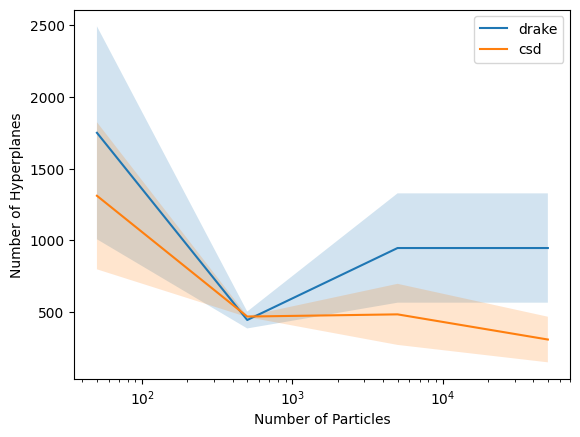

In [75]:
import matplotlib.pyplot as plt
import numpy as np
field = 'num_faces'
plot_name = {
    'num_faces': "Number of Hyperplanes",
    'time': "Time [s]",
}


plt.figure()
for k in ['drake', 'csd']:
    x = list(agg_data_sets['drake'].keys())
    y = []
    y_err = []
    for nump in agg_data_sets['drake'].keys():
        data_nump = np.mean(agg_data_sets[k][nump][field])
        y.append(data_nump)
        y_err.append(np.std(agg_data_sets[k][nump][field]))
    y_err = np.array(y_err)
    y = np.array(y)
    plt.semilogx(x,y, label= k)
    plt.fill_between(x, y-y_err, y+y_err, alpha = 0.2)
    plt.legend()
    plt.xlabel('Number of Particles')
    plt.ylabel(plot_name[field])

In [47]:
np.mean(agg_data_sets['drake'][50000]['time'])

np.float64(6.964693470001221)

In [32]:
import numpy as np
for k in keys:
    if k =='region':
        continue
    d = agg_data['drake'][k]
    c = agg_data['csd'][k] 
    s = f"""{k}
drake: {np.mean(d):.3f} +-{np.std(d):.3f}
csd: {np.mean(c):.3f} +-{np.std(c):.3f}
"""
    print(s)

el_vol
drake: 0.000 +-0.000
csd: 0.000 +-0.000

num_faces
drake: 933.800 +-157.144
csd: 790.800 +-118.009

time
drake: 9.066 +-2.318
csd: 2.022 +-0.529

frac_in_collision
drake: 0.005 +-0.001
csd: 0.005 +-0.001

seed_point_idx
drake: 0.000 +-0.000
csd: 0.000 +-0.000

trial_idx
drake: 4.500 +-2.872
csd: 4.500 +-2.872

num_particles
drake: 50.000 +-0.000
csd: 50.000 +-0.000



In [27]:
keys

dict_keys(['el_vol', 'num_faces', 'time', 'frac_in_collision', 'seed_point_idx', 'trial_idx', 'num_particles', 'region'])

In [18]:
import numpy as np
print('drake')
print(f'num data points {len(num_faces_drake)}')
print(f'mean {np.mean(num_faces_drake)}')
print(f'std {np.std(num_faces_drake)}')
print(f'med {np.median(num_faces_drake)}')

print('csd')
print(f'num data points{len(num_faces_csd)}')
print(f'mean {np.mean(num_faces_csd)}')
print(f'std {np.std(num_faces_csd)}')
print(f'med {np.median(num_faces_csd)}')

drake
num data points 10
mean 933.8
std 157.143755841586
med 877.0
csd
num data points10
mean 790.8
std 118.00915218744687
med 742.5
